In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt






In [7]:
# Đường dẫn dataset của bạn
image_dir = r"D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\data\fer-2013_image\train"

all_pixels = []

In [8]:
# Duyệt qua các thư mục để lấy mẫu pixel
# Vì dataset rất lớn, ta lấy mẫu khoảng 1000 ảnh ngẫu nhiên để vẽ histogram cho nhanh
all_image_paths = []
for root, dirs, files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append(os.path.join(root, file))

# Lấy mẫu tối đa 1000 ảnh (hoặc ít hơn nếu dataset nhỏ)
if len(all_image_paths) == 0:
    print(f"Không tìm thấy ảnh trong thư mục: {image_dir}")
else:
    sample_size = min(1000, len(all_image_paths))
    sample_paths = np.random.choice(all_image_paths, sample_size, replace=False)

    for path in sample_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten())

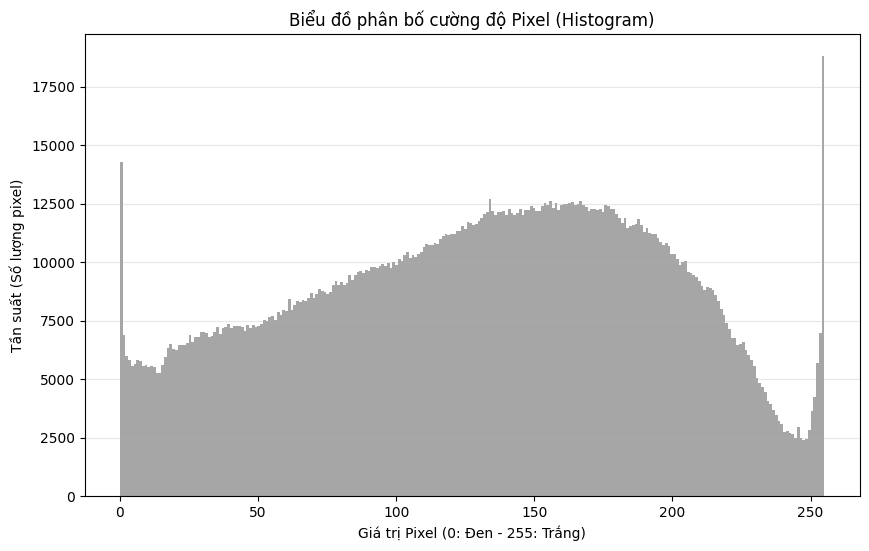

In [9]:

# Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
plt.hist(all_pixels, bins=256, range=[0, 255], color='gray', alpha=0.7)
plt.title('Biểu đồ phân bố cường độ Pixel (Histogram)')
plt.xlabel('Giá trị Pixel (0: Đen - 255: Trắng)')
plt.ylabel('Tần suất (Số lượng pixel)')
plt.grid(axis='y', alpha=0.3)
plt.show()